<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellmender import denoise_count_matrix
from cellmender.simulation import simulate_cells
import cellmender.utils as cm_utils
from cellmender.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping

cellmender_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellmender"

# import importlib
# import cellmender.celltype_ambient
# importlib.reload(cellmender.celltype_ambient)
# from cellmender.celltype_ambient import denoise_count_matrix

# import importlib
# import cellmender.utils as cm_utils
# importlib.reload(cm_utils)
# from cellmender.utils import plot_matrix_scatterplot

# Compare CellBender vs. cellmender

Some datasets of use:
- tiny mouse heart dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0

In [3]:
dataset_name = "pbmc8k"  # options: tiny_cellbender, pbmc8k, simulation1, custom
rerun_alternate_tools = False  # if True, requires docker
cellbender_model = "full"  # options: ambient, swapping, full
wompwomp_path = os.path.join(os.path.dirname(cellmender_dir), "wompwomp")  # only needed if dataset_name == "custom"
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False
# cellbender_env = "/home/jrich/miniconda3/envs/cellbender"
wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"
scar_env = "/home/jrich/miniconda3/envs/scar"
use_cuda = False
threads = 16

# only required if dataset_name == "custom"; if using a dataset option above, then this will override the defaults filled out below
adata_path_raw_custom = None
adata_path_cellmender_custom = None
adata_path_cellbender_custom = None
soupx_out_prefix_custom = None
decontx_out_prefix_custom = None
adata_path_scar_custom = None
sequencing_technology_custom = None
model_pkl_custom = None
matrix_tar_files_dir_custom = None
raw_tar_file_dir_custom = None
filtered_tar_file_dir_custom = None
cellmender_max_iter_custom = None
cellmender_beta_custom = None
cellmender_cell_ambient_fraction_custom = None
cellbender_epochs_custom = None
cellbender_fpr_custom = None
scar_epochs_custom = None
cellbender_total_droplets_custom = None
expected_cells_custom = None
cs_empty_threshold_custom = None
min_genes_custom = None
min_cells_custom = None
umi_top_percentile_to_remove_custom = None
unique_genes_top_percentile_to_remove_custom = None
mt_gene_percentile_to_remove_custom = None
max_mt_percentage_custom = None
n_top_genes_custom = None
n_pcs_custom = None
n_neighbors_custom = None
leiden_resolution_custom = None
marker_genes_custom = None

In [4]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

cellbender_matrix_url = None
cellbender_matrix_filtered_url = None
cellbender_ckpt_url = None
soupx_matrix_url = None
decontx_matrix_url = None
scar_matrix_url = None

cellmender_log_file = os.path.join(data_dir, "cellmender.log")
cellbender_ckpt = os.path.join(out_dir, "cellbender_ckpt.tar.gz")

if dataset_name == "tiny_cellbender":
    adata_path_raw = f"{data_dir}/tiny_raw_feature_bc_matrix.h5ad"
    adata_path_cellmender = f"{data_dir}/tiny_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/tiny_output_cellbender.h5"
    soupx_out_prefix = None  # f"{data_dir}/tiny_output_soupx"
    decontx_out_prefix = None  # f"{data_dir}/tiny_output_decontx"
    adata_path_scar = None
    sequencing_technology = "10XV2"
    model_pkl = "Adult_Mouse_Gut.pkl"  # path to celltypist model pkl file - this is a mouse heart dataset, but this is really just for debugging anyways
    
    if not os.path.exists(adata_path_raw):
        raise FileNotFoundError(f"Original matrix file not found: {adata_path_raw}. Create with CellBender's `python generate_tiny_10x_dataset.py` (see https://github.com/broadinstitute/CellBender):")
    
    matrix_tar_files_dir = None
    raw_tar_file_dir = None
    filtered_tar_file_dir = None

    cellbender_matrix_url = None
    cellbender_matrix_filtered_url = None
    cellbender_ckpt_url = None
    soupx_matrix_url = None
    decontx_matrix_url = None

    cellmender_max_iter = 10
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 2
    cellbender_fpr = 0.01
    cellbender_total_droplets = 2000
    scar_epochs = 2
    expected_cells = 500
    cs_empty_threshold = 1000
    min_genes = 5
    min_cells = 3
    umi_top_percentile_to_remove = None
    unique_genes_top_percentile_to_remove = None
    mt_gene_percentile_to_remove = None
    max_mt_percentage = 50
    n_top_genes = 2000
    n_pcs = 45
    n_neighbors = 15
    leiden_resolution = 1.0
    marker_genes = {
        'Resting CD4+ T cells': ["Hbb-bs", "mt-Co3", "mt-Atp6"],
        'Paneth.progenitor': ["Eef1a1"],
        'Plasma cell': ["H3f3b"],
        'Naive B cells': ["Rpl13", "Rplp0"]
    }
elif dataset_name == "pbmc8k":
    adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    adata_path_cellmender = f"{data_dir}/pbmc8k_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/pbmc8k_output_cellbender.h5"
    soupx_out_prefix = f"{data_dir}/pbmc8k_output_soupx"
    decontx_out_prefix = f"{data_dir}/pbmc8k_output_decontx"
    adata_path_scar = f"{data_dir}/pbmc8k_output_scar.h5ad"
    sequencing_technology = "10XV2"
    model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
    
    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
    if not os.path.exists(raw_tar_file_dir):
        raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir):
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}

    cellbender_matrix_url = "https://caltech.box.com/shared/static/trxd26eqmr33cg3ot0l3jins9s193ob6.h5"
    cellbender_matrix_filtered_url = "https://caltech.box.com/shared/static/bnilabzuvdvtm1knpsfgy89php938qft.h5"
    cellbender_ckpt_url = "https://caltech.box.com/shared/static/hj41un9dz0pk5j10t8dyfj2mbllzrp6s.gz"
    soupx_matrix_url = "https://caltech.box.com/shared/static/7lhpw8bgwf3b3gyl7wgqe15h3yhxamld.gz"
    decontx_matrix_url = "https://caltech.box.com/shared/static/zzfs06lp634g2rhuuph200rvga08atzh.gz"
    scar_matrix_url = ""
    
    cellmender_max_iter = 40
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 150
    cellbender_fpr = 0.01
    cellbender_total_droplets = 12_000
    scar_epochs = 200
    expected_cells = 9000
    cs_empty_threshold = 10
    min_genes = 0
    min_cells = 0
    umi_top_percentile_to_remove = 5
    unique_genes_top_percentile_to_remove = 5
    mt_gene_percentile_to_remove = 10
    max_mt_percentage = None
    n_top_genes = 2000
    n_pcs = 25
    n_neighbors = 20
    leiden_resolution = 1.0
    marker_genes = {
        "Monocytes/neutrophils": ["S100A8", "S100A9", "S100A12", "FCGR3A"],
        "Monocytes/pDCs": ["LYZ", "CST3", "FCN1", "LILRA4"],
        "T": ["IL32", "TRAC", "CCR7", "FOXP3", "CD8A", "CD8B", "NKG7", "GNLY", "TRGC1", "SLC4A10"],
        "B": ["IGHD", "CD79A", "FCER2", "TNFRSF13B"],
        "NK": ["KLRF1", "SPON2"],
        "Progenitor": ["PPBP"],
        "Baso./neutro./progenitor": ["SDPR", "CLU"],
        "(Broad expression)": ["PTPRC"]
    }
# elif dataset_name == "simulation1":
#     if not os.path.exists(adata_path_raw):
#         adata = cm_utils.simulate_cells(adata_path_raw, ...)
    
#     paths = cm_utils.write_10x_like(adata, matrix_tar_files_dir)

#     # # soupx inputs
#     # matrix_tar_files_dir = matrix_tar_files_dir
#     adata_soupx_obs_csv = paths["celltypes"]
#     # soupx_out_prefix

#     # # decontx inputs
#     raw_tar_file_dir = paths["raw"]
#     filtered_tar_file_dir = paths["filtered"]
#     sequencing_technology = paths["technology"]
#     # decontx_out_prefix
#     #!!! continue filling out

# set any custom variables provided by the user
for var in ["adata_path_raw", "adata_path_cellmender", "adata_path_cellbender", "soupx_out_prefix", "decontx_out_prefix", "sequencing_technology", "model_pkl", "matrix_tar_files_dir", "raw_tar_file_dir", "filtered_tar_file_dir", "cellmender_max_iter", "cellmender_beta", "cellmender_cell_ambient_fraction", "cellbender_epochs", "cellbender_fpr", "cellbender_total_droplets", "scar_epochs", "expected_cells", "cs_empty_threshold", "min_genes", "min_cells", "umi_top_percentile_to_remove", "unique_genes_top_percentile_to_remove", "mt_gene_percentile_to_remove", "max_mt_percentage", "n_top_genes", "n_pcs", "n_neighbors", "leiden_resolution", "marker_genes"]:
    custom = globals().get(f"{var}_custom")
    if custom is not None:
        globals()[var] = custom

adata_path_cellbender_filtered = adata_path_cellbender.replace(".h5", "_filtered.h5")

## Raw

In [5]:
if adata_path_raw.endswith(".h5ad"):
    adata_raw = ad.read_h5ad(adata_path_raw)
elif adata_path_raw.endswith(".h5"):
    adata_raw = sc.read_10x_h5(adata_path_raw)
else:
    raise ValueError(f"Original matrix file must be either .h5ad or .h5 format. Found: {adata_path_raw}")
adata_raw.var_names_make_unique()

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (9000): 298.00


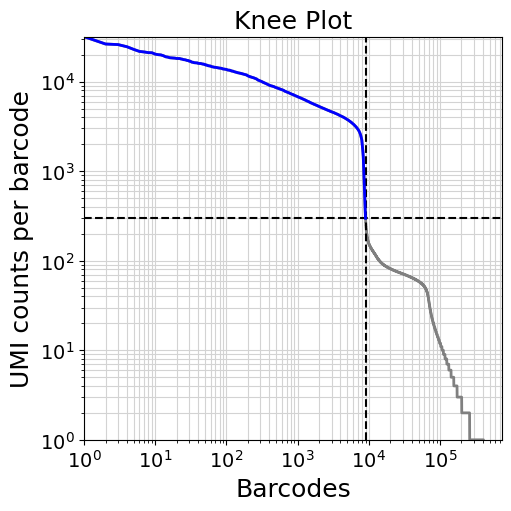

In [6]:
umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

In [7]:
# umi_cutoff = 0  #!!! optionally update from knee plot

## cellmender

In [8]:
%%time
if not os.path.exists(adata_path_cellmender) or overwrite:
    adata = adata_raw.copy()
    adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
    _ = denoise_count_matrix(adata, adata_out=adata_path_cellmender, max_iter=cellmender_max_iter, beta=cellmender_beta, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=cellmender_cell_ambient_fraction, verbose=verbose, log_file=cellmender_log_file)

CPU times: user 57 μs, sys: 2 μs, total: 59 μs
Wall time: 163 μs


In [9]:
adata_cellmender = ad.read_h5ad(adata_path_cellmender)
adata_cellmender = adata_cellmender[~adata_cellmender.obs["is_empty"]].copy()
adata_cellmender.var_names_make_unique()
print(f"Counts are less than or equal check for CellMender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellmender)}")

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Counts are less than or equal check for CellMender: True


## CellBender (v0.3.0)

In [12]:
runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
output_path = adata_path_cellbender.replace(f"{cellmender_dir}/notebooks/data", "/data")
# conda_run_flag = "-p" if "/" in cellbender_env else "-n"
# !conda run {conda_run_flag} {cellbender_env} \ 
!echo docker run --rm -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
    bash -c "cellbender remove-background \
        --input {input_path} \
        --output {output_path} \
        --expected-cells {expected_cells} \
        --total-droplets-included {cellbender_total_droplets} \
        --epochs {cellbender_epochs} \
        --fpr {cellbender_fpr} \
        --model {cellbender_model} \
        {runtime} && \
        mv ckpt.tar.gz {out_dir}/cellbender_ckpt.tar.gz"

docker run --rm -v /home/jrich/Desktop/cellmender/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 bash -c cellbender remove-background          --input /data/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5          --output /data/pbmc8k/pbmc8k_output_cellbender.h5          --expected-cells 9000          --total-droplets-included 12000          --epochs 150          --fpr 0.01          --model full          --cpu-threads 16 &&          mv ckpt.tar.gz /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/cellbender_ckpt.tar.gz


In [10]:
%%time
if not os.path.exists(adata_path_cellbender) or overwrite:
     if rerun_alternate_tools:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellmender_dir}/notebooks/data", "/data")
          !docker run --rm -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c \"cellbender remove-background \
               --input {input_path} \
               --output {output_path} \
               --expected-cells {expected_cells} \
               --total-droplets-included {cellbender_total_droplets} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --model {cellbender_model} \
               {runtime} \&\& \
               mv ckpt.tar.gz {out_dir}/cellbender_ckpt.tar.gz\"
     else:
          !wget -O {adata_path_cellbender} {cellbender_matrix_url}
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

CPU times: user 60 μs, sys: 4 μs, total: 64 μs
Wall time: 77 μs


In [24]:
# adata_cellbender_with_empty_droplets = anndata_from_h5(adata_path_cellbender)
# adata_cellbender = adata_cellbender_with_empty_droplets[adata_cellbender_with_empty_droplets.obs['cell_probability'] > 0.5]
adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
adata_cellbender.var_names_make_unique()
print(f"Counts are less than or equal check for CellBender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellbender)}")

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Counts are less than or equal check for CellBender: True


## SoupX (v1.6.2)

In [25]:
%%time
if soupx_out_prefix and (not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite):
    if rerun_alternate_tools:
        adata_soupx_obs_csv = f"{data_dir}/pbmc8k_soupx_obs.csv"
        if not os.path.exists(adata_soupx_obs_csv) or overwrite:
            adata_soupx_tmp = cm_utils.load_adata(filtered_tar_file_dir)
            adata_soupx_tmp = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata_soupx_tmp.obs.to_csv(adata_soupx_obs_csv)

        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellmender_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellmender_dir, rver_docker_workspace)}
    else:
        !wget -O {soupx_out_prefix}.tar.gz {soupx_matrix_url}
        !tar -xvzf {soupx_out_prefix}.tar.gz -C {os.path.dirname(soupx_out_prefix)}

CPU times: user 481 μs, sys: 0 ns, total: 481 μs
Wall time: 368 μs


In [26]:
adata_soupx = cm_utils.read_r_matrix_into_anndata(soupx_out_prefix)
adata_soupx.var_names_make_unique()
print(f"Counts are less than or equal check for SoupX: {cm_utils.check_counts_less_equal(adata_raw, adata_soupx)}")

Counts are less than or equal check for SoupX: True


## DecontX (v1.8.0)

In [27]:
%%time
if decontx_out_prefix and (not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite):
    if rerun_alternate_tools:
        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {sequencing_technology} \
                {decontx_out_prefix.replace(cellmender_dir, rver_docker_workspace)}
    else:
        !wget -O {decontx_out_prefix}.tar.gz {decontx_matrix_url}
        !tar -xvzf {decontx_out_prefix}.tar.gz -C {os.path.dirname(decontx_out_prefix)}

CPU times: user 0 ns, sys: 679 μs, total: 679 μs
Wall time: 495 μs


In [28]:
adata_decontx = cm_utils.read_r_matrix_into_anndata(decontx_out_prefix)
adata_decontx.obs_names = [name.replace("GRCh38_", "", 1) for name in adata_decontx.obs_names]
adata_decontx.var_names_make_unique()
print(f"Counts are less than or equal check for DecontX: {cm_utils.check_counts_less_equal(adata_raw, adata_decontx)}")

Counts are less than or equal check for DecontX: True


## scAR (v0.7.0)

In [49]:
%%time
rerun_alternate_tools = True
if adata_path_scar and (not os.path.exists(adata_path_scar) or overwrite):
     if rerun_alternate_tools:
          runtime = "--cuda" if use_cuda else ""
          conda_run_flag = "-p" if "/" in scar_env else "-n"
          !conda run {conda_run_flag} {scar_env} \
            python {cellmender_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir} \
            -f {filtered_tar_file_dir} \
            -o {adata_path_scar} \
            {runtime} \
            --epochs {scar_epochs}
     else:
          !wget -O {adata_path_scar} {scar_matrix_url}

1128.11s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Loading data...
Preprocessing data...
Setting up AnnData for scAR...
Running scAR...
Training: 100%|██████████| 200/200 [20:52<00:00,  6.26s/it, Loss=4.2196e+03] 
Performing inference...
Saving results...

2025-11-15 06:31:14|INFO|setup_anndata|Use all 261019 droplets.
2025-11-15 06:31:16|INFO|setup_anndata|Estimating ambient profile for ['Gene Expression']...
2025-11-15 06:32:00|INFO|setup_anndata|Iteration: 1
2025-11-15 06:32:42|INFO|setup_anndata|Iteration: 2
2025-11-15 06:33:25|INFO|setup_anndata|Iteration: 3
2025-11-15 06:33:25|INFO|setup_anndata|Estimated ambient profile for Gene Expression saved in adata.uns
2025-11-15 06:33:25|INFO|setup_anndata|Estimated ambient profile for all features saved in adata.uns
2025-11-15 06:33:29|INFO|model|cpu will be used.
2025-11-15 06:33:29|INFO|model|Found ambient profile in AnnData.uns['ambient_profile_all']
2025-11-15 06:33:29|INFO|VAE|Running VAE using the following param set:
2025-11-15 06:33:29|INFO|VAE|...denoised count type: mRNA
2025-1

In [50]:
adata_scar = None
if adata_path_scar:
    adata_scar = ad.read_h5ad(adata_path_scar)
    adata_scar.var_names_make_unique()
    print(f"Counts are less than or equal check for CellMender: {cm_utils.check_counts_less_equal(adata_raw, adata_scar)}")

Counts are less than or equal check for CellMender: False


# Analysis

In [52]:
print(f"Raw:\n{adata_raw}\n\n")
print(f"cellmender:\n{adata_cellmender}\n\n")
print(f"CellBender:\n{adata_cellbender}\n\n")
print(f"SoupX:\n{adata_soupx}\n\n")
print(f"DecontX:\n{adata_decontx}\n\n")
print(f"scAR:\n{adata_scar}\n\n")

Raw:
AnnData object with n_obs × n_vars = 737280 × 33694
    var: 'gene_ids'


cellmender:
AnnData object with n_obs × n_vars = 9000 × 33694
    obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat', 'leiden', 'broad_celltype'
    var: 'gene_ids', 'ambient_fraction', 'ambient_hat', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'beta_hat', 'celltype_names', 'celltype_profile', 'celltype_profile_genes', 'loglike', 'p_hat', 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'over_clustering'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'denoised', 'counts'
    obsp: 'distances', 'connectivities'


CellBender:
AnnData object with n_obs × n_vars = 8752 × 33694
    obs: 'leiden', 'celltype', 'broad_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'over_clustering'
    obsm: 'X_pca'
    v

## UpSet plot of retained cells

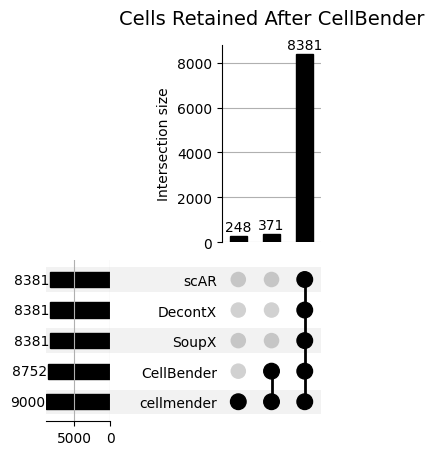

In [51]:
upset_data_dict = {
    # "Raw": set(adata_raw.obs_names),
    "cellmender": set(adata_cellmender.obs_names),
    "CellBender": set(adata_cellbender.obs_names),
    "SoupX": set(adata_soupx.obs_names) if adata_soupx is not None else None,
    "DecontX": set(adata_decontx.obs_names) if adata_decontx is not None else None,
    "scAR": set(adata_scar.obs_names) if adata_scar is not None else None
}

_ = cm_utils.make_upset_plot(upset_data_dict, title="Cells Retained After CellBender", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Scatterplot of cell x gene expression differences

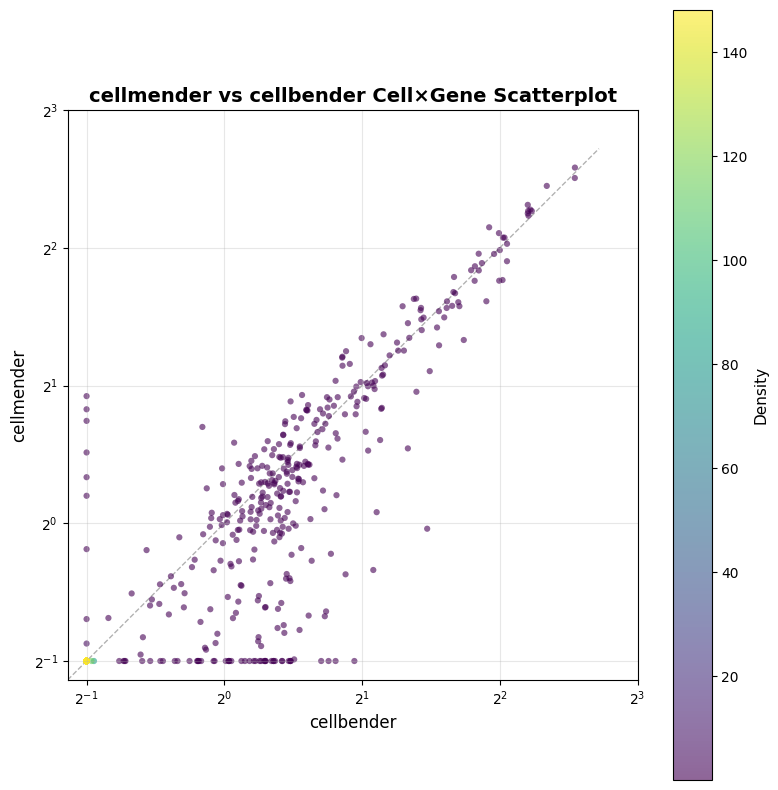

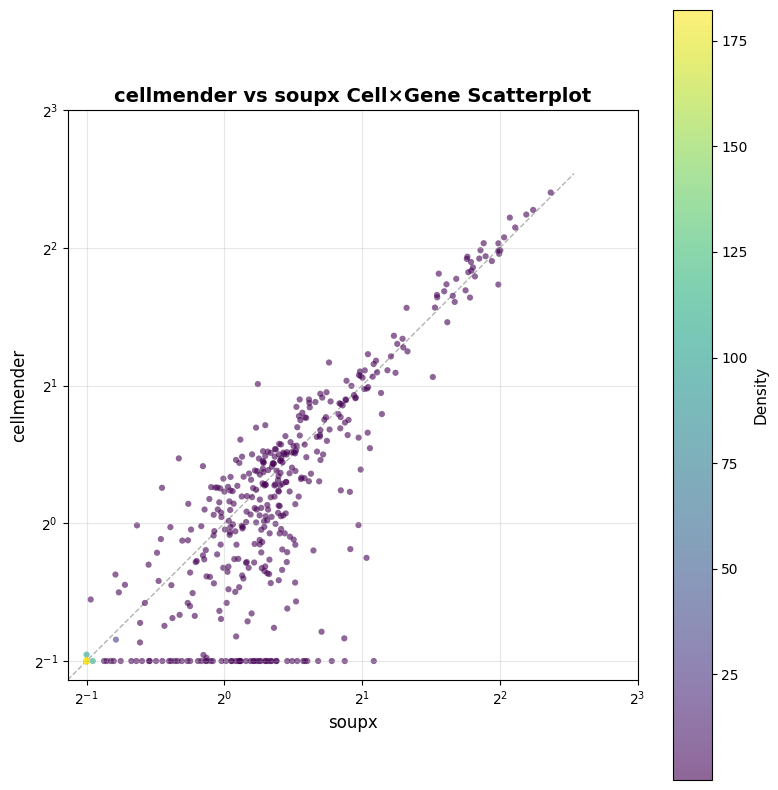

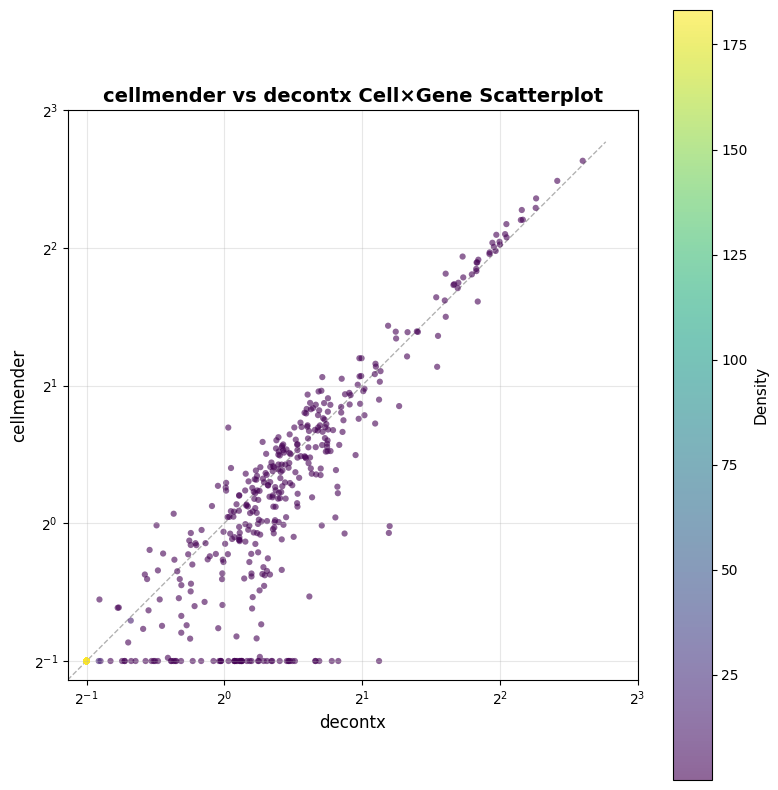

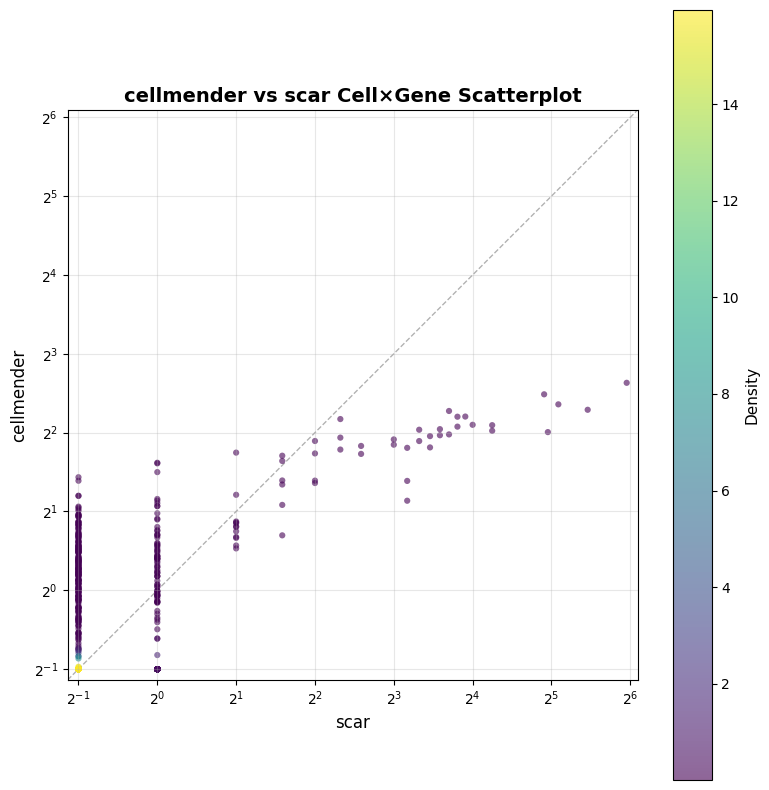

In [53]:
max_points = 10_000
cm_utils.plot_matrix_scatterplot(adata_cellbender, adata_cellmender, scale="log", x_axis="cellbender", y_axis="cellmender", max_points=max_points, out_path=os.path.join(out_dir, f"cellmender_vs_cellbender_expression_scatterplot_{max_points}points.png"), show=True)
if adata_soupx:
    cm_utils.plot_matrix_scatterplot(adata_soupx, adata_cellmender, scale="log", x_axis="soupx", y_axis="cellmender", max_points=max_points, out_path=os.path.join(out_dir, f"cellmender_vs_soupx_expression_scatterplot_{max_points}points.png"), show=True)
if adata_decontx:
    cm_utils.plot_matrix_scatterplot(adata_decontx, adata_cellmender, scale="log", x_axis="decontx", y_axis="cellmender", max_points=max_points, out_path=os.path.join(out_dir, f"cellmender_vs_decontx_expression_scatterplot_{max_points}points.png"), show=True)
if adata_scar:
    cm_utils.plot_matrix_scatterplot(adata_scar, adata_cellmender, scale="log", x_axis="scar", y_axis="cellmender", max_points=max_points, out_path=os.path.join(out_dir, f"cellmender_vs_scar_expression_scatterplot_{max_points}points.png"), show=True)

## Histogram of per-cell Pearson correlations

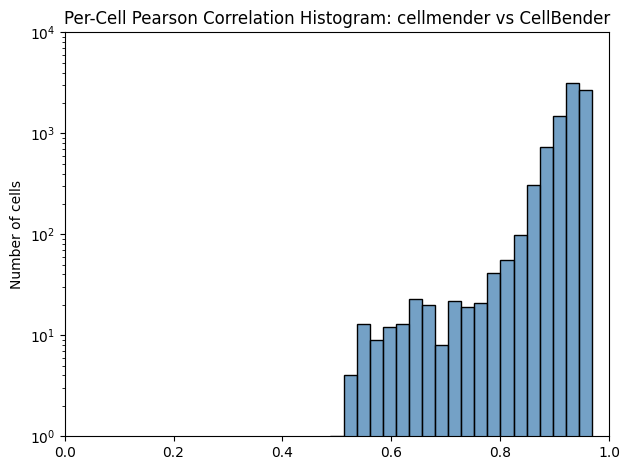

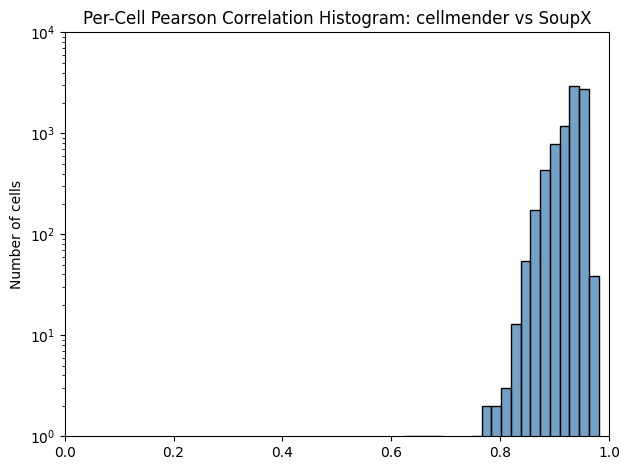

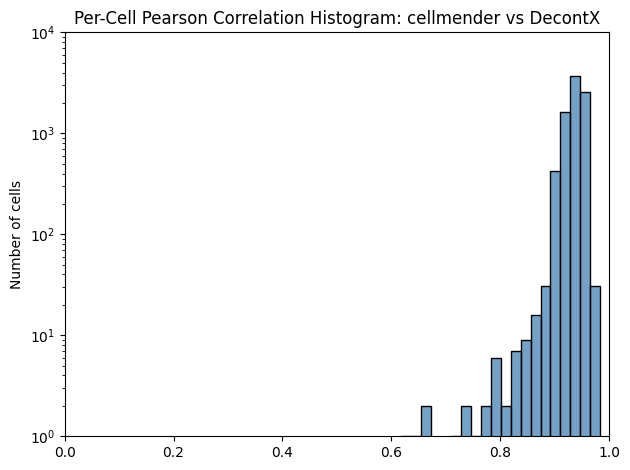

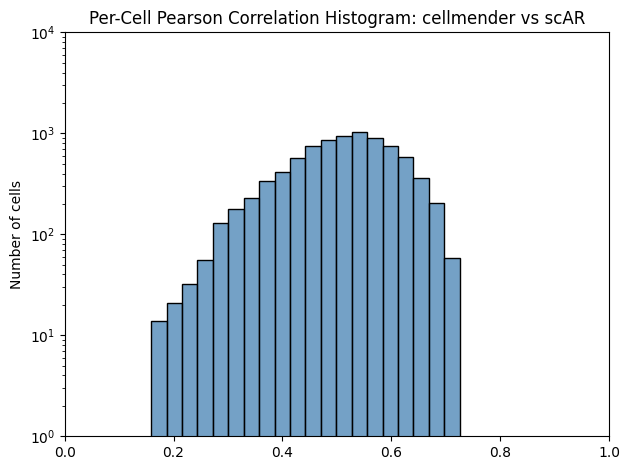

In [54]:
cm_utils.plot_per_cell_correlation(adata_cellmender, adata_cellbender, title="Per-Cell Pearson Correlation Histogram: cellmender vs CellBender", out_path=os.path.join(out_dir, "cellmender_vs_cellbender_per_cell_correlation.png"))
if adata_soupx:
    cm_utils.plot_per_cell_correlation(adata_cellmender, adata_soupx, title="Per-Cell Pearson Correlation Histogram: cellmender vs SoupX", out_path=os.path.join(out_dir, "cellmender_vs_soupx_per_cell_correlation.png"))
if adata_decontx:
    cm_utils.plot_per_cell_correlation(adata_cellmender, adata_decontx, title="Per-Cell Pearson Correlation Histogram: cellmender vs DecontX", out_path=os.path.join(out_dir, "cellmender_vs_decontx_per_cell_correlation.png"))
if adata_scar:
    cm_utils.plot_per_cell_correlation(adata_cellmender, adata_scar, title="Per-Cell Pearson Correlation Histogram: cellmender vs scAR", out_path=os.path.join(out_dir, "cellmender_vs_scar_per_cell_correlation.png"))

## Deviation from raw

Total differences for cellmender: 23,274,065.961670846


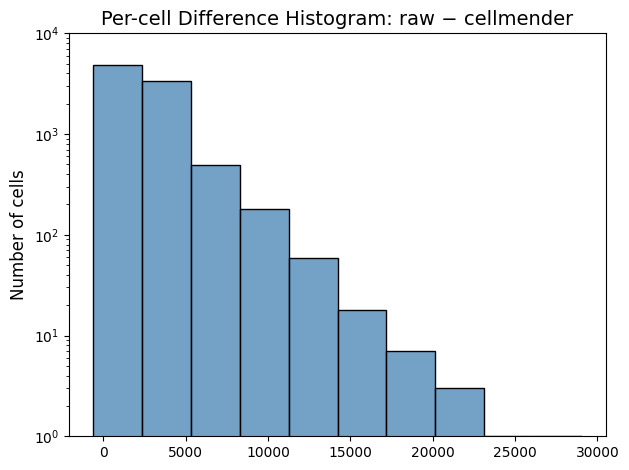

Total differences for CellBender: 21,420,020.0


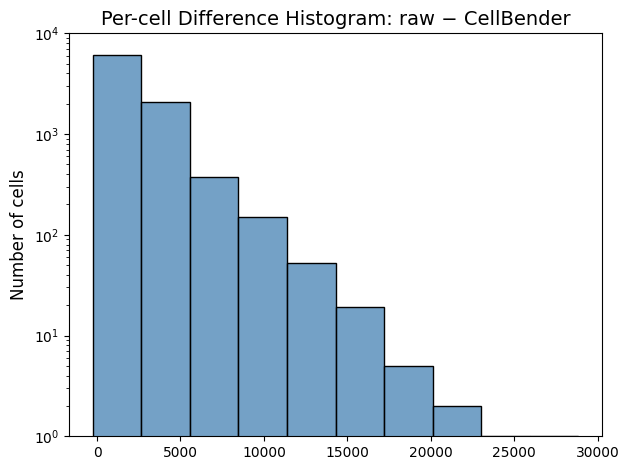

Total differences for SoupX: 21,271,566.5799696


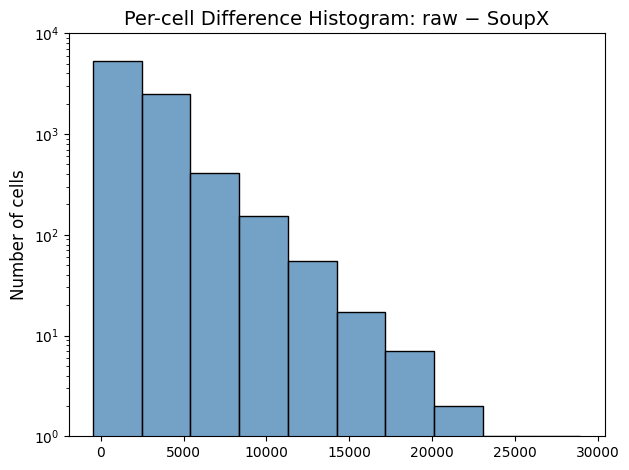

Total differences for DecontX: 21,380,742.74466395


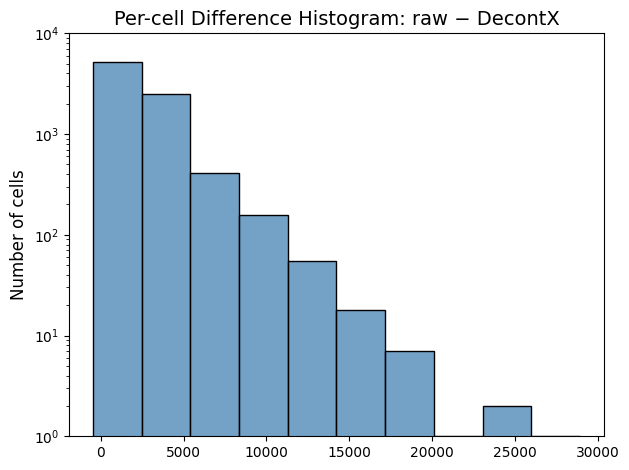

Total differences for scAR: 18,157,591.0


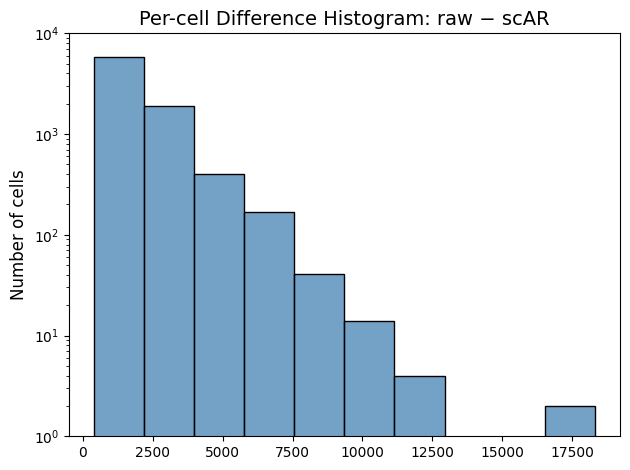

In [55]:
cm_utils.plot_per_cell_difference(adata_raw, adata_cellmender, tool="cellmender", out_path=os.path.join(out_dir, "cellmender_per_cell_absolute_difference_from_raw.png"))
cm_utils.plot_per_cell_difference(adata_raw, adata_cellbender, tool="CellBender", out_path=os.path.join(out_dir, "cellbender_per_cell_absolute_difference_from_raw.png"))
if adata_soupx:
    cm_utils.plot_per_cell_difference(adata_raw, adata_soupx, tool="SoupX", out_path=os.path.join(out_dir, "soupx_per_cell_absolute_difference_from_raw.png"))
if adata_decontx:
    cm_utils.plot_per_cell_difference(adata_raw, adata_decontx, tool="DecontX", out_path=os.path.join(out_dir, "decontx_per_cell_absolute_difference_from_raw.png"))
if adata_scar:
    cm_utils.plot_per_cell_difference(adata_raw, adata_scar, tool="scAR", out_path=os.path.join(out_dir, "scar_per_cell_absolute_difference_from_raw.png"))

## stop here for tiny dataset

In [56]:
# if dataset_name == "tiny_cellbender":
#     sys.exit()

## Alluvial plot of cluster differences

In [57]:
adata_cellmender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellmender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellmender = cm_utils.determine_cell_types(adata_cellmender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

adata_cellbender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellbender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellbender = cm_utils.determine_cell_types(adata_cellbender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_soupx:
    adata_soupx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx = cm_utils.determine_cell_types(adata_soupx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_decontx:
    adata_decontx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_decontx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_decontx = cm_utils.determine_cell_types(adata_decontx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_scar:
    adata_scar = cm_utils.run_scanpy_preprocessing_and_clustering(adata_scar, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_scar = cm_utils.determine_cell_types(adata_scar, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

06:59:51 - INFO - Adata initial shape: (9000, 33694)
06:59:51 - INFO - Done!
06:59:52 - INFO - Running cell type annotation using CellTypist with model_pkl=Immune_All_High.pkl. This may take some time depending on the size of the dataset and the model used.
📂 Storing models in /home/jrich/.celltypist/data/models
⏩ Skipping [1/58]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/58]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/58]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/58]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/58]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/58]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/58]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/58]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/58]: Adult_Human_Vascular.pkl (file exists)
⏩ Skipping [10/58]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [11/58]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [12/58]: Adult_Pig_Hippocam

🗳️ Majority voting the predictions
✅ Majority voting done!


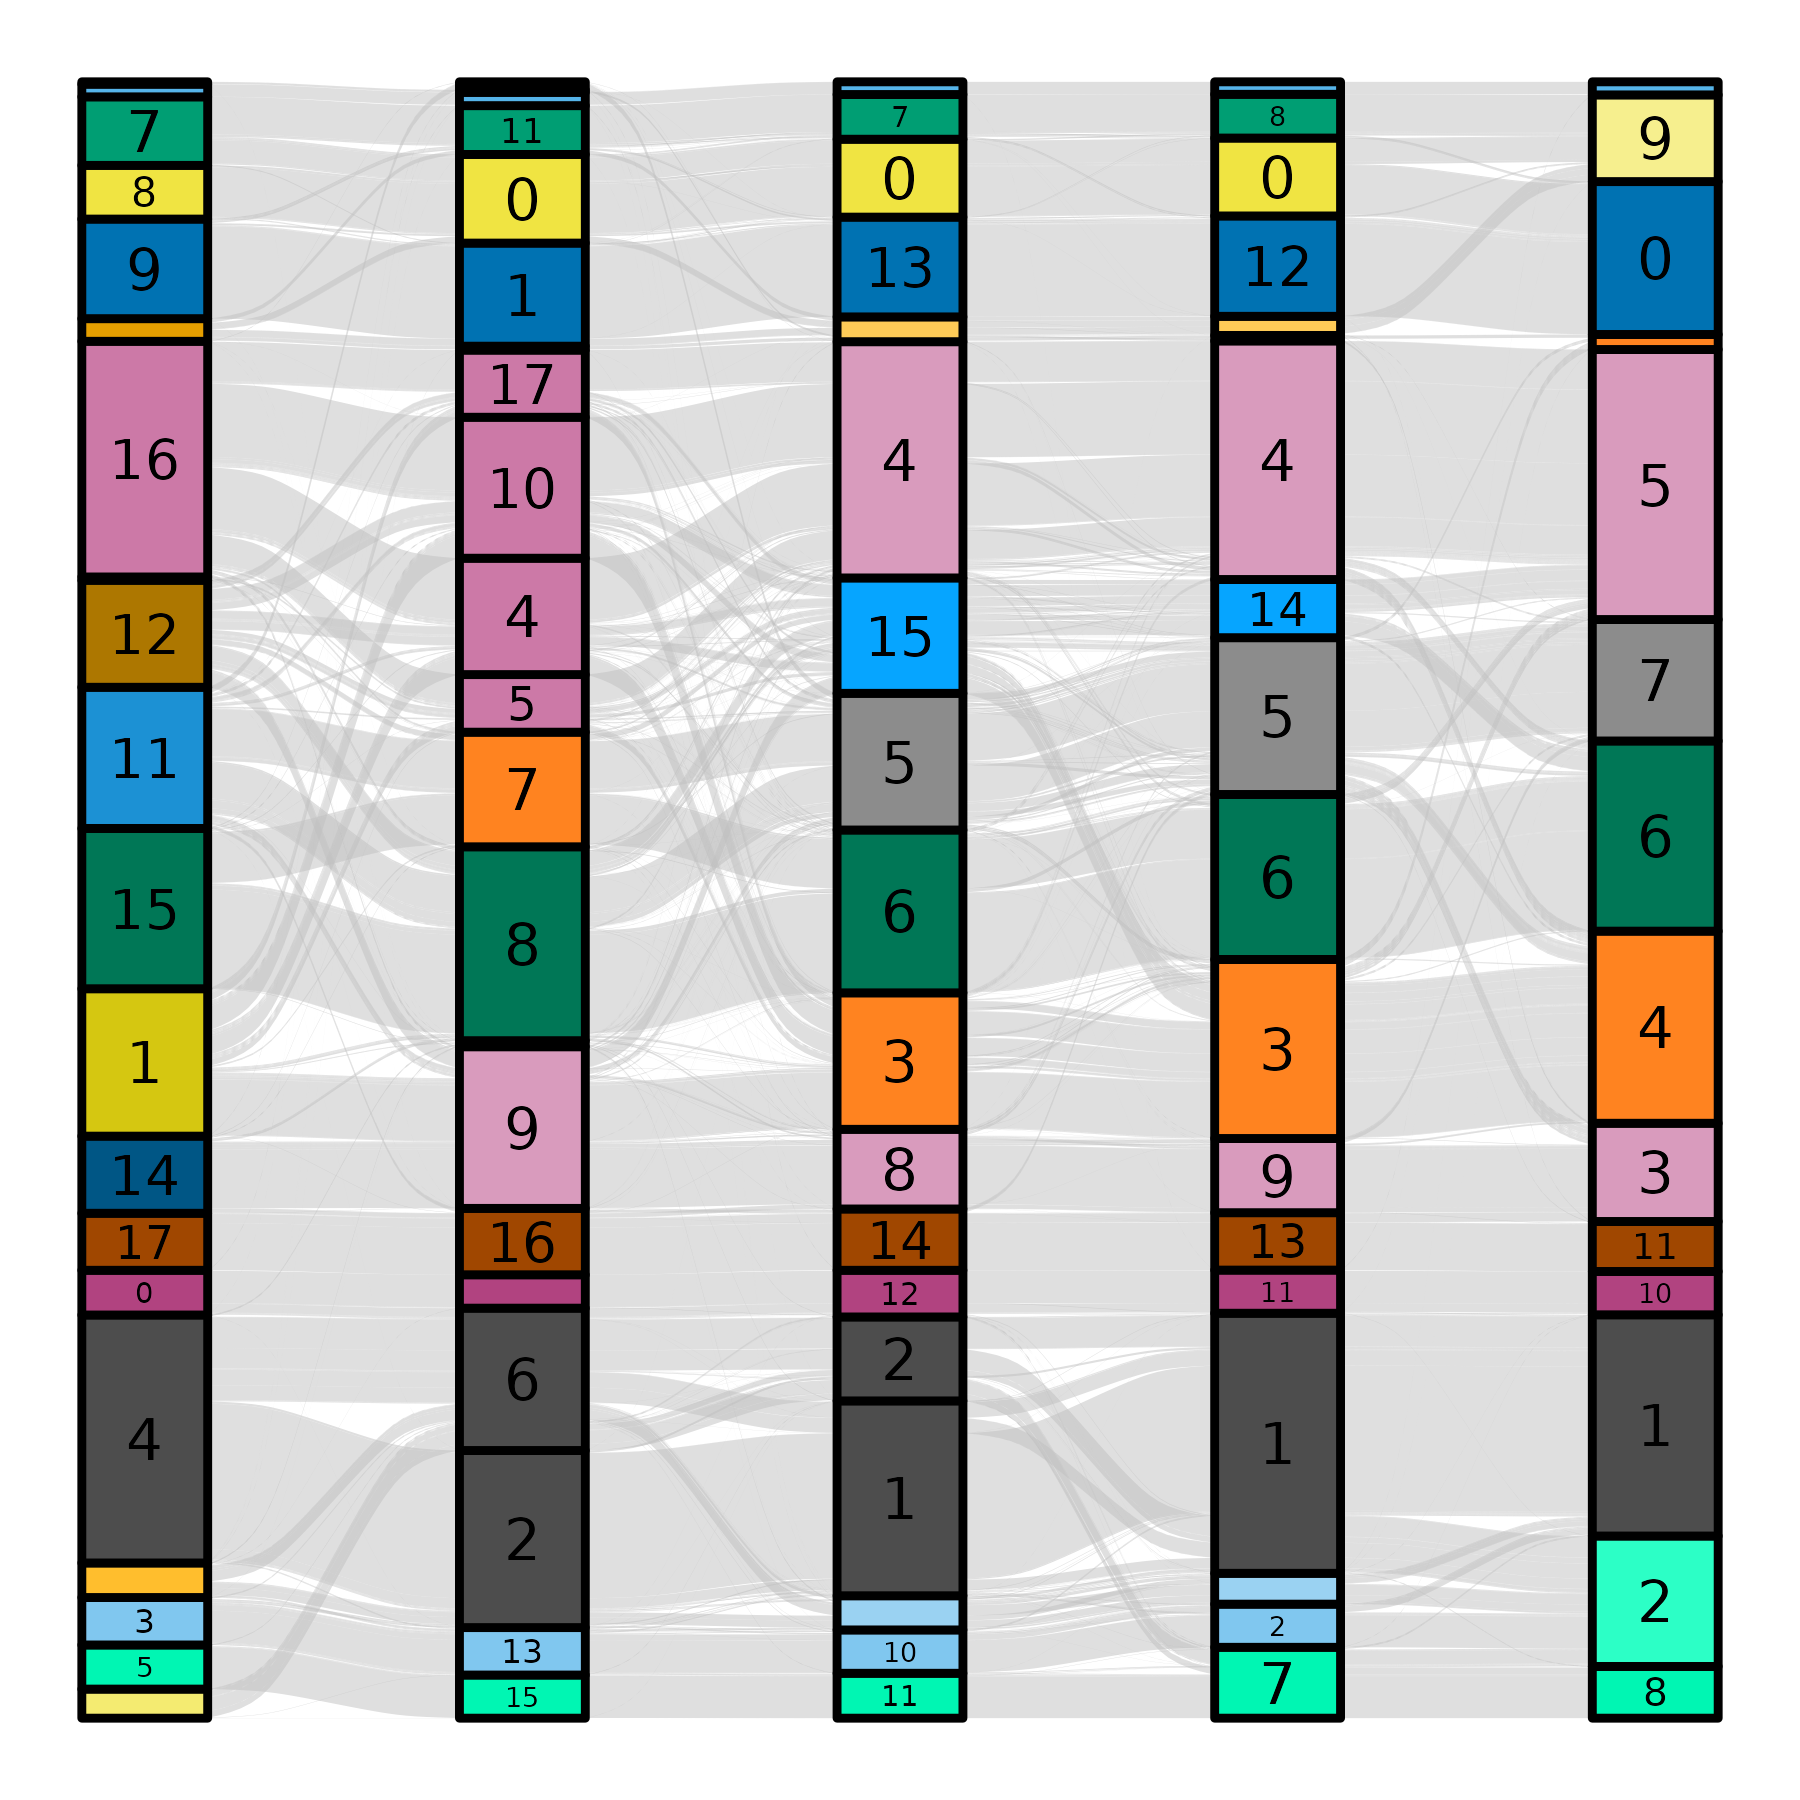

07:00:30 - INFO - Running wompwomp for celltype
07:00:30 - DEBUG - conda run -p /home/jrich/miniconda3/envs/wompwomp_env /home/jrich/Desktop/wompwomp/exec/wompwomp plot_alluvial --df /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_celltype_df.csv --graphing_columns cellbender cellmender soupx decontx scAR --coloring_algorithm left --disable_optimize_column_order -o /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_celltype.png


[1] "Plot saved to: /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_celltype.png"



Warning messages:
1: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
2: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
3: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.



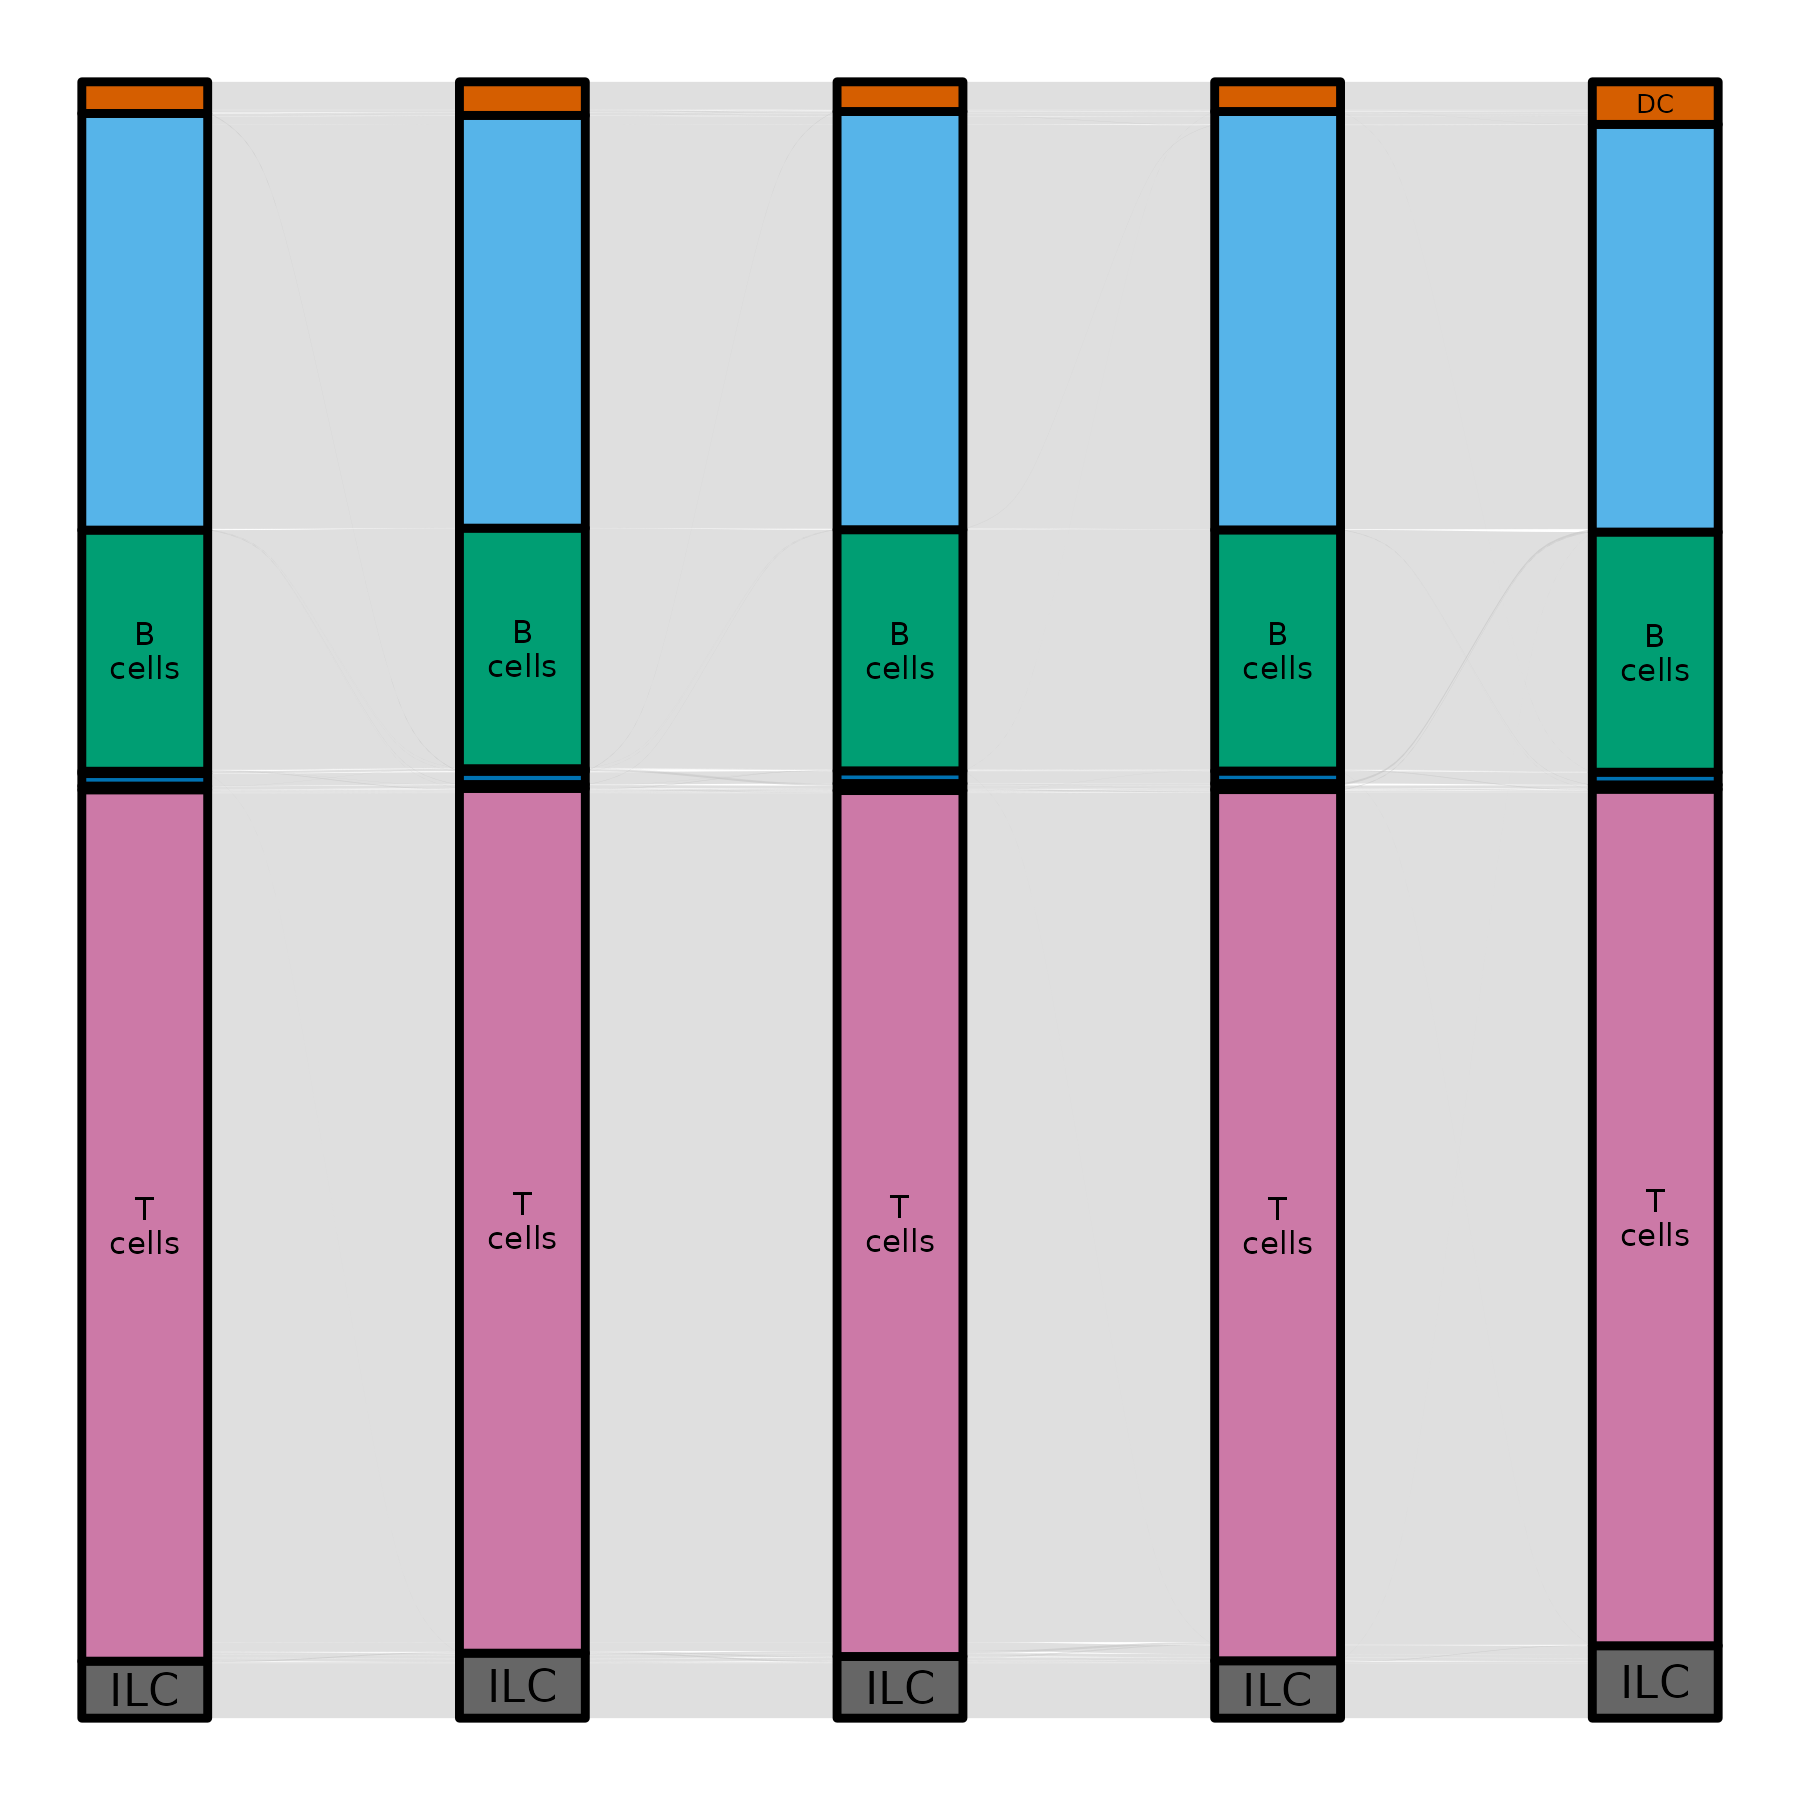

In [58]:
col_names = ["cellbender", "cellmender", "soupx", "decontx", "scAR"]

# wrap in try-except block to catch errors due to wompwomp installation issues
try:
    # wompwomp_leiden_df = cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="leiden", merged_df_csv=os.path.join(out_dir, "alluvial_cluster_df.csv"), out_path=os.path.join(out_dir, "alluvial_cluster.png"), wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env, verbose=verbose)
    display(Image(filename=os.path.join(out_dir, "alluvial_cluster.png")))

    wompwomp_celltype_df = cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="celltype", merged_df_csv=os.path.join(out_dir, "alluvial_celltype_df.csv"), out_path=os.path.join(out_dir, "alluvial_celltype.png"), wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env, verbose=verbose)
    display(Image(filename=os.path.join(out_dir, "alluvial_celltype.png")))
except Exception as e:
    print(f"Error generating alluvial plots with wompwomp: {e}")

## Dot plots

In [59]:
# print(adata.obs["celltype"].value_counts())

# from celltypist import models
# model = models.Model.load(model_pkl)
# print(model.cell_types)

In [60]:
if dataset_name == "pbmc8k":
    # Map fine-grained cell types to broad categories for matching to CellBender Fig 2
    reverse_map = {fine: broad for broad, fine_list in CellBender_Fig2_to_Immune_All_High_celltype_mapping.items() for fine in fine_list}
    adata_cellmender.obs["broad_celltype"] = adata_cellmender.obs["celltype"].map(reverse_map).fillna("Other")
    adata_cellbender.obs["broad_celltype"] = adata_cellbender.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_soupx:
        adata_soupx.obs["broad_celltype"] = adata_soupx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_decontx:
        adata_decontx.obs["broad_celltype"] = adata_decontx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_scar:
        adata_scar.obs["broad_celltype"] = adata_scar.obs["celltype"].map(reverse_map).fillna("Other")
    celltype_column_dotplot = "broad_celltype"
else:
    celltype_column_dotplot = "celltype"

... storing 'broad_celltype' as categorical


scAR Raw Data Dotplot


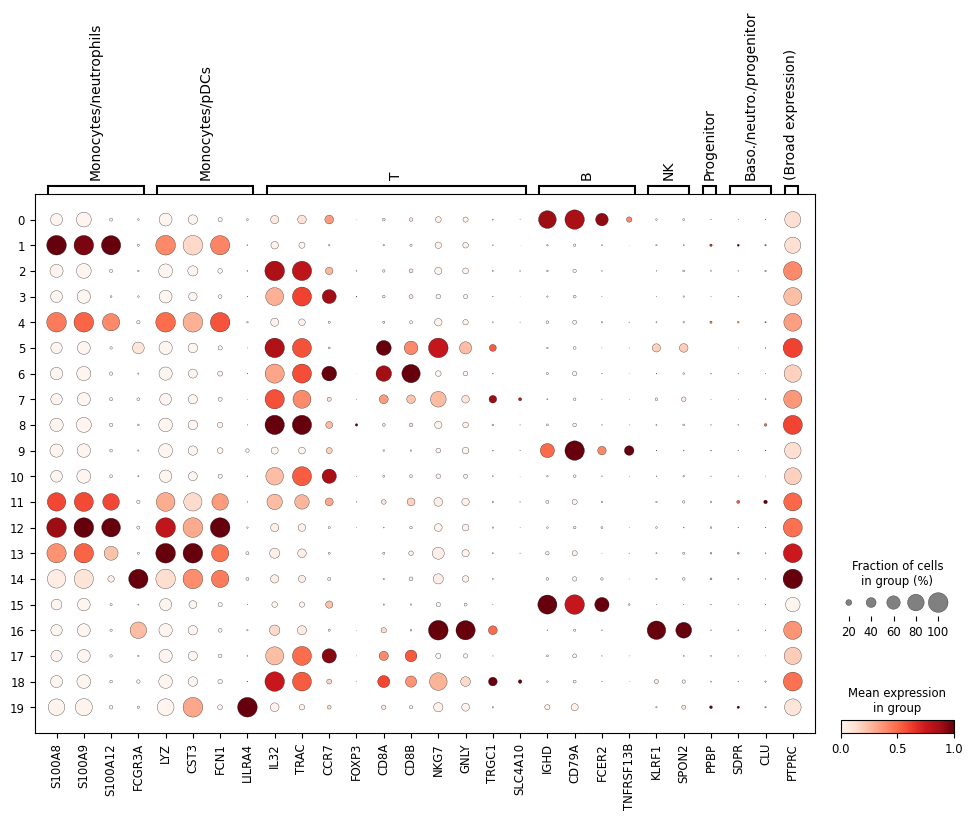

... storing 'broad_celltype' as categorical


------------------------------
scAR Processed Data Dotplot


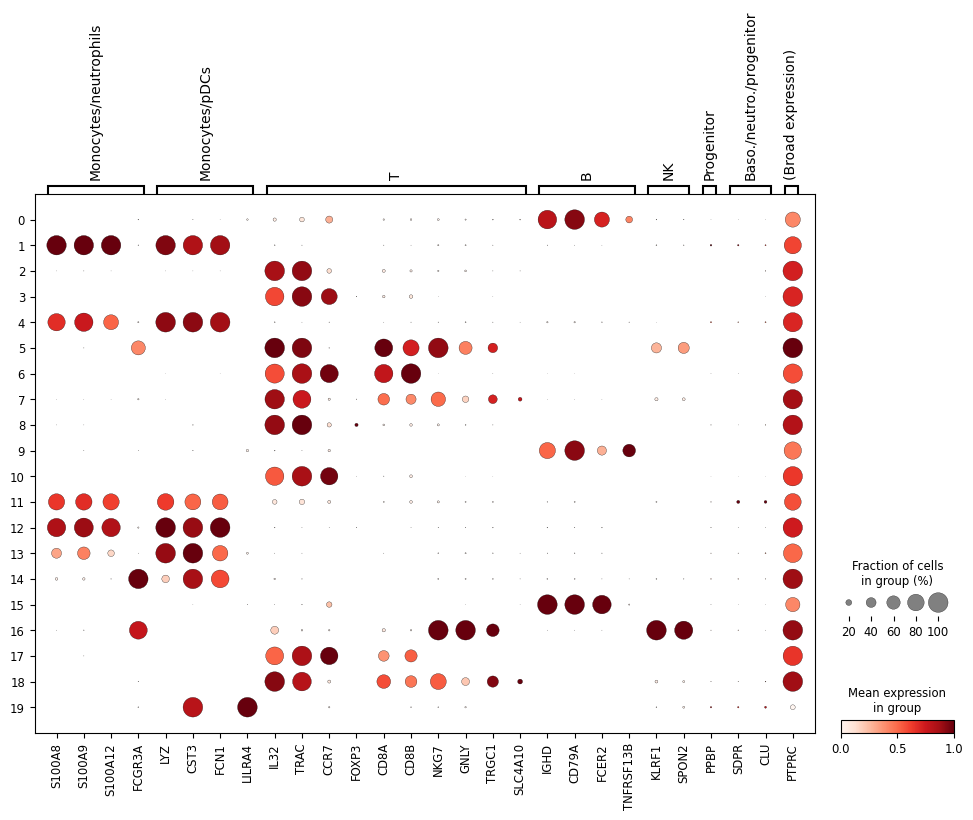

------------------------------


In [61]:
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar.png"))

... storing 'broad_celltype' as categorical


CellMender Raw Data Dotplot


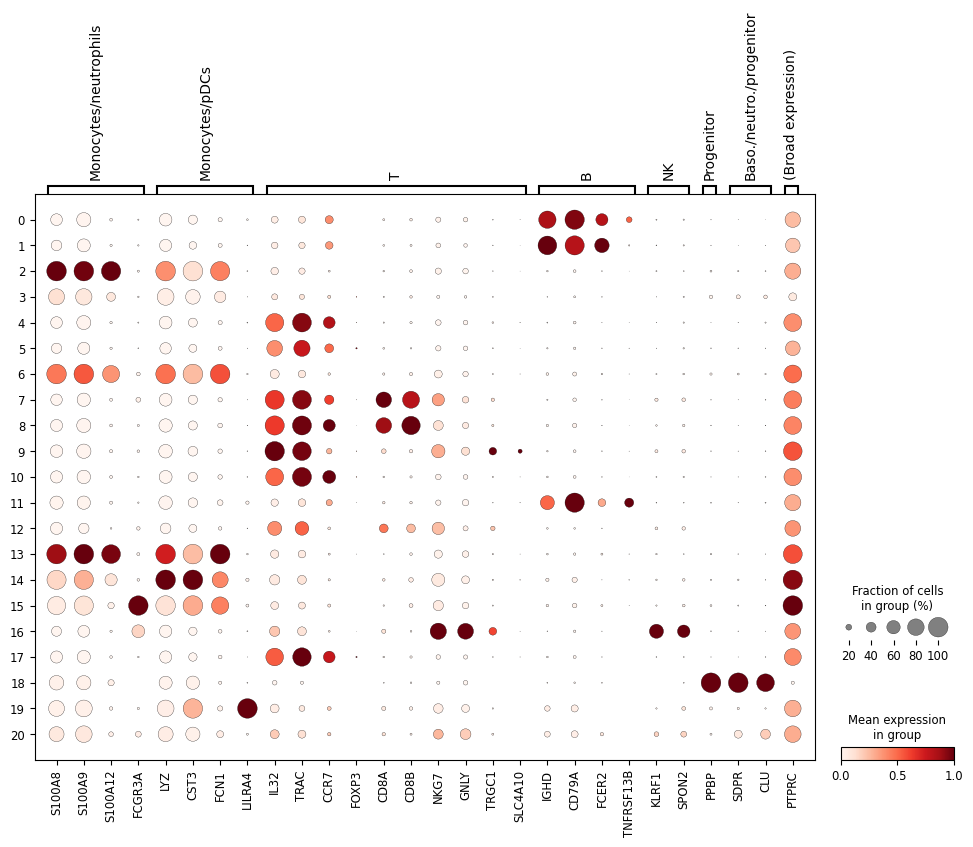

... storing 'broad_celltype' as categorical


------------------------------
CellMender Processed Data Dotplot


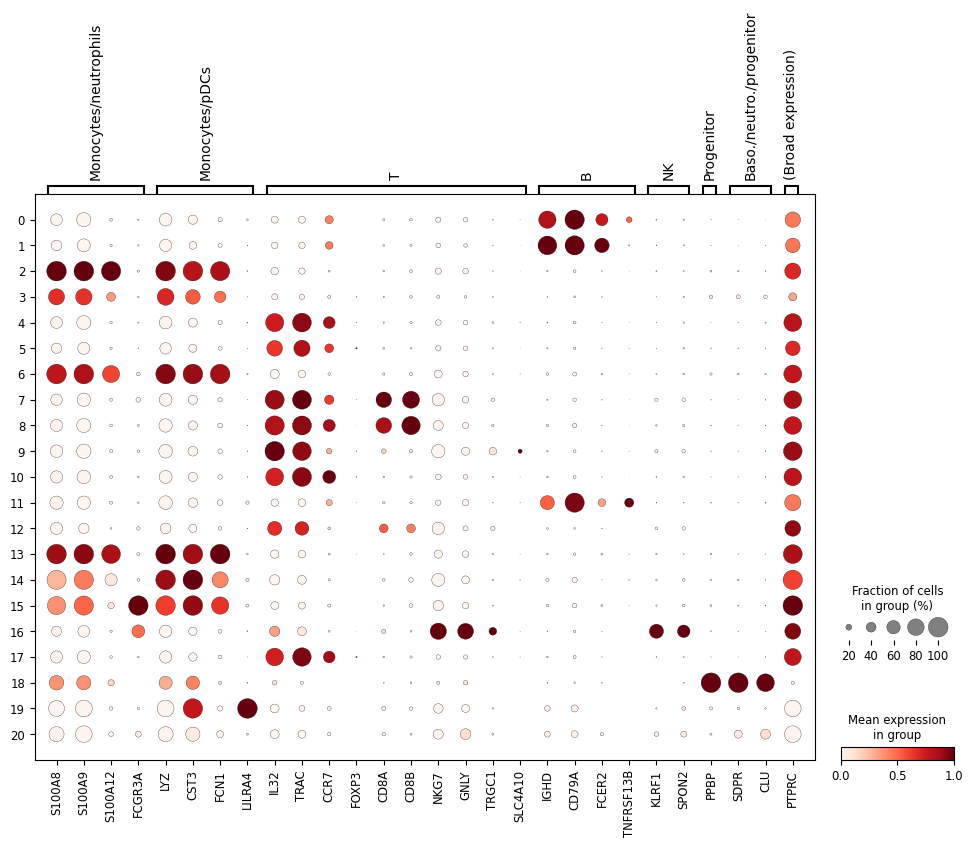

... storing 'broad_celltype' as categorical


------------------------------
CellBender Raw Data Dotplot


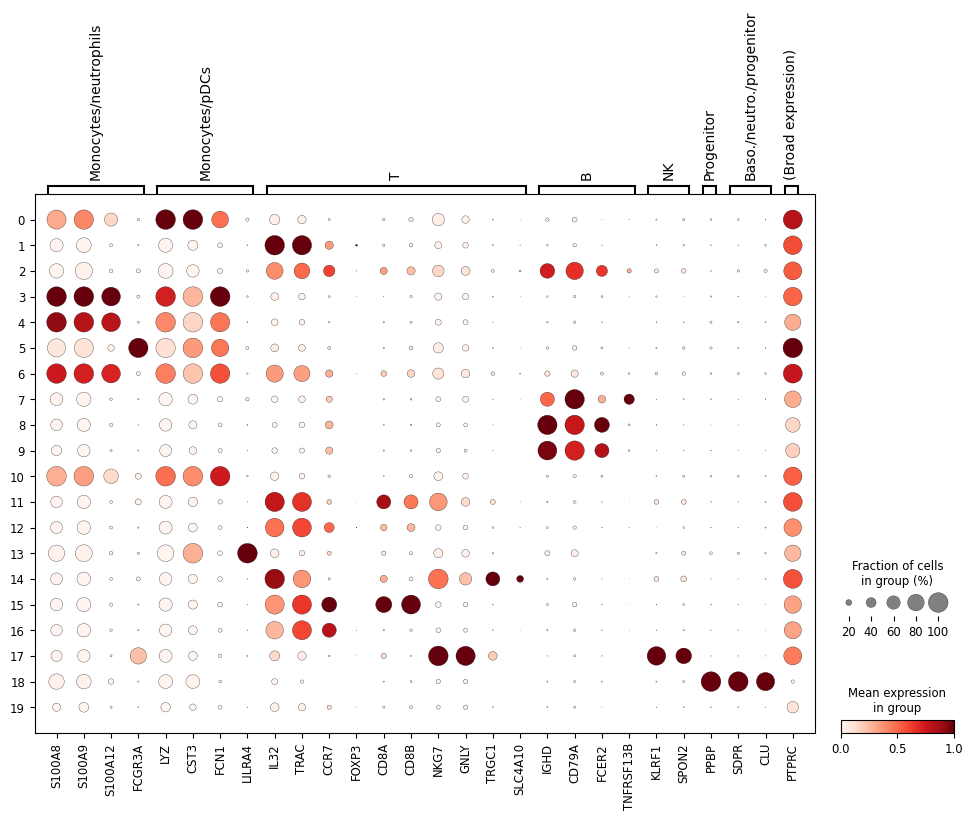

... storing 'broad_celltype' as categorical


------------------------------
CellBender Processed Data Dotplot


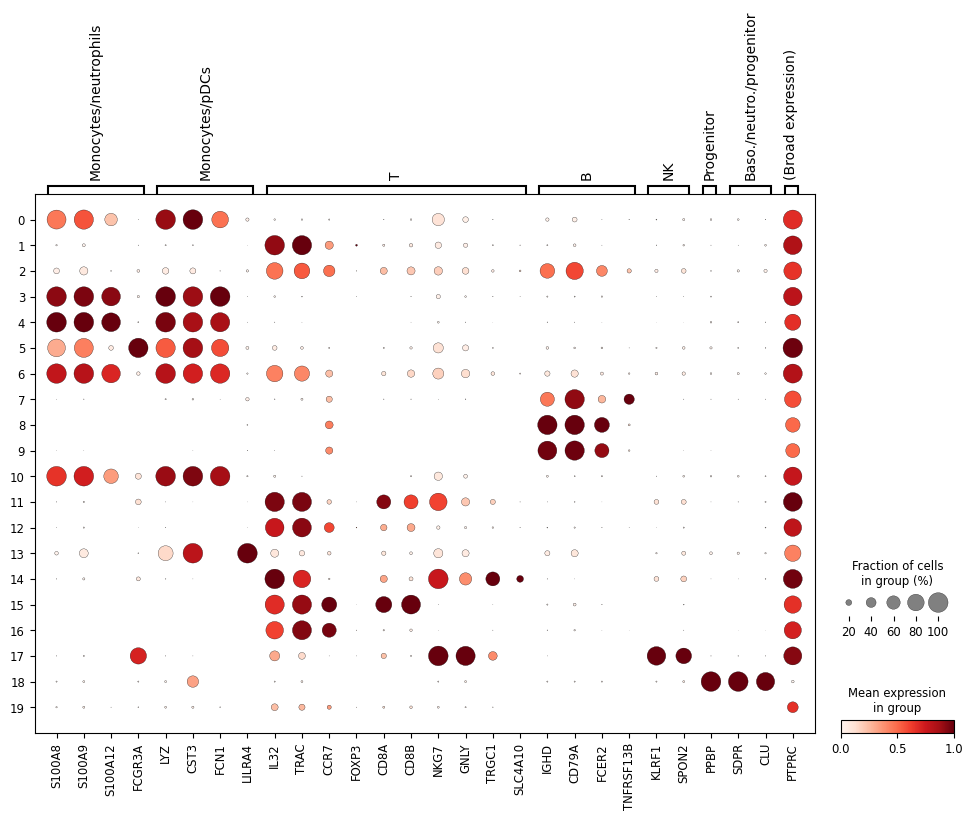

... storing 'broad_celltype' as categorical


------------------------------
SoupX Raw Data Dotplot


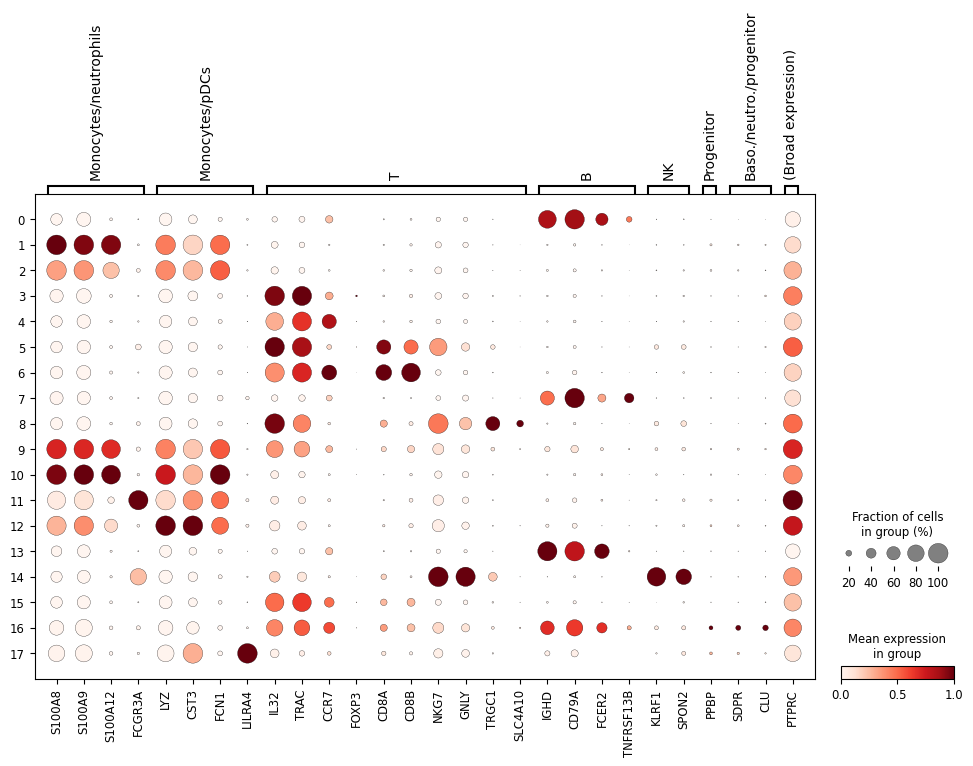

... storing 'broad_celltype' as categorical


------------------------------
SoupX Processed Data Dotplot


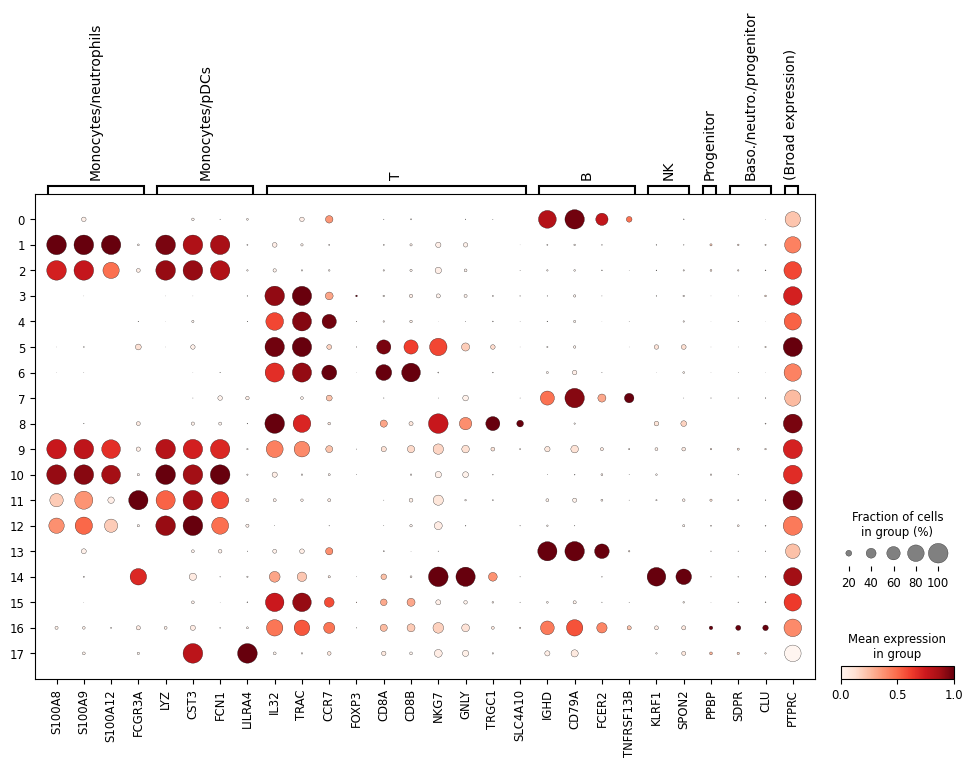

... storing 'broad_celltype' as categorical


------------------------------
DecontX Raw Data Dotplot


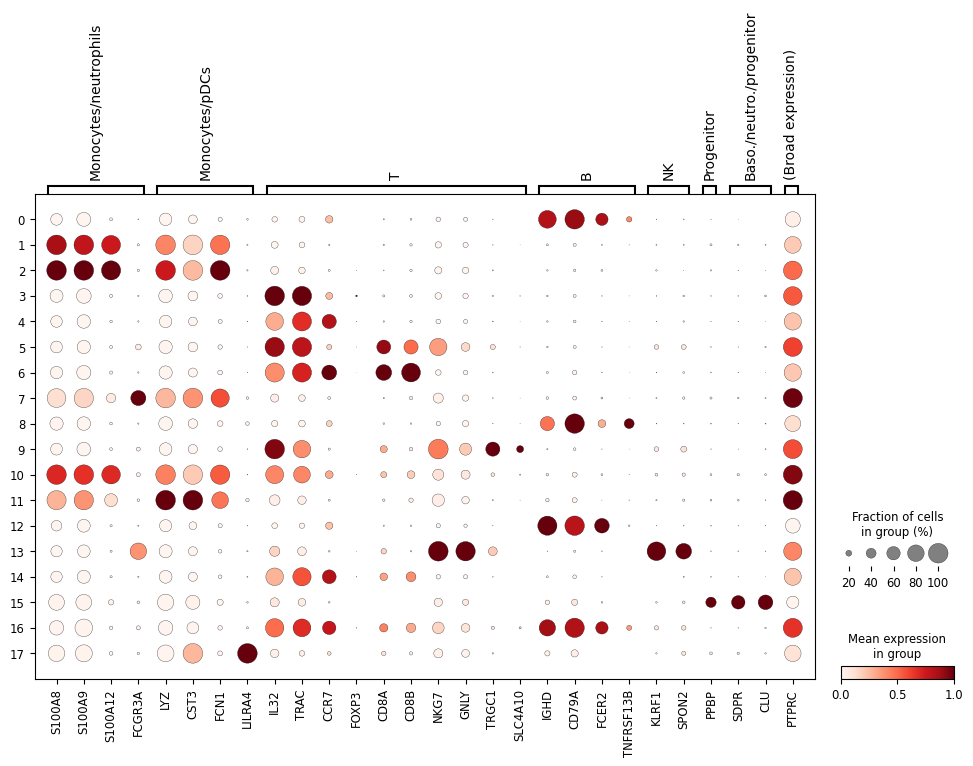

... storing 'broad_celltype' as categorical


------------------------------
DecontX Processed Data Dotplot


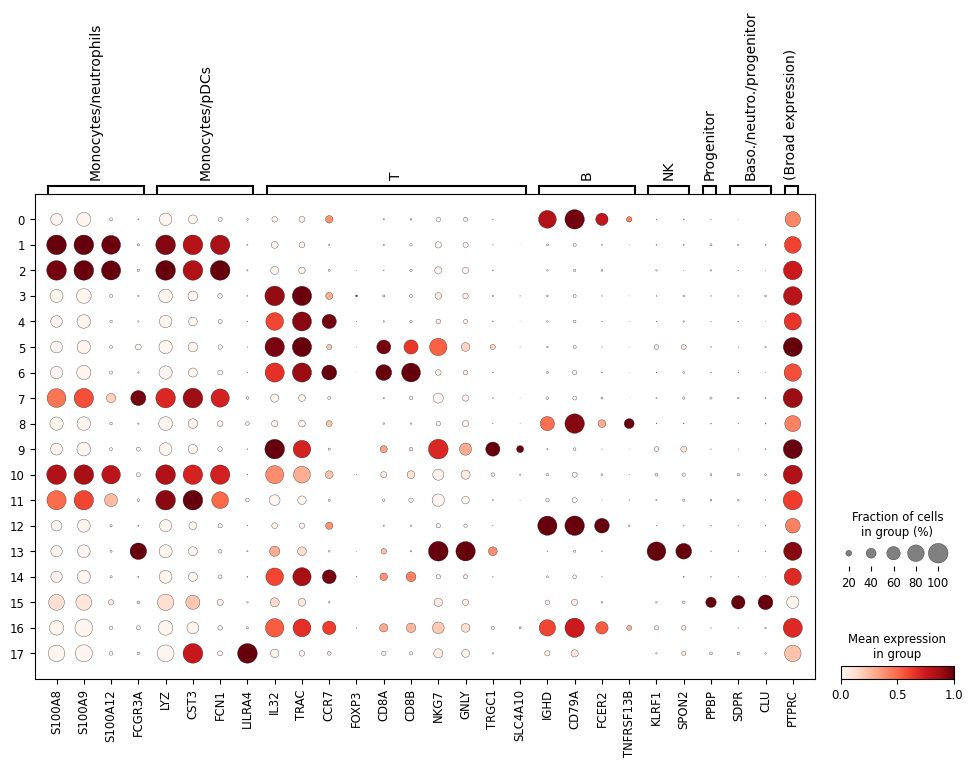

------------------------------
scAR Raw Data Dotplot


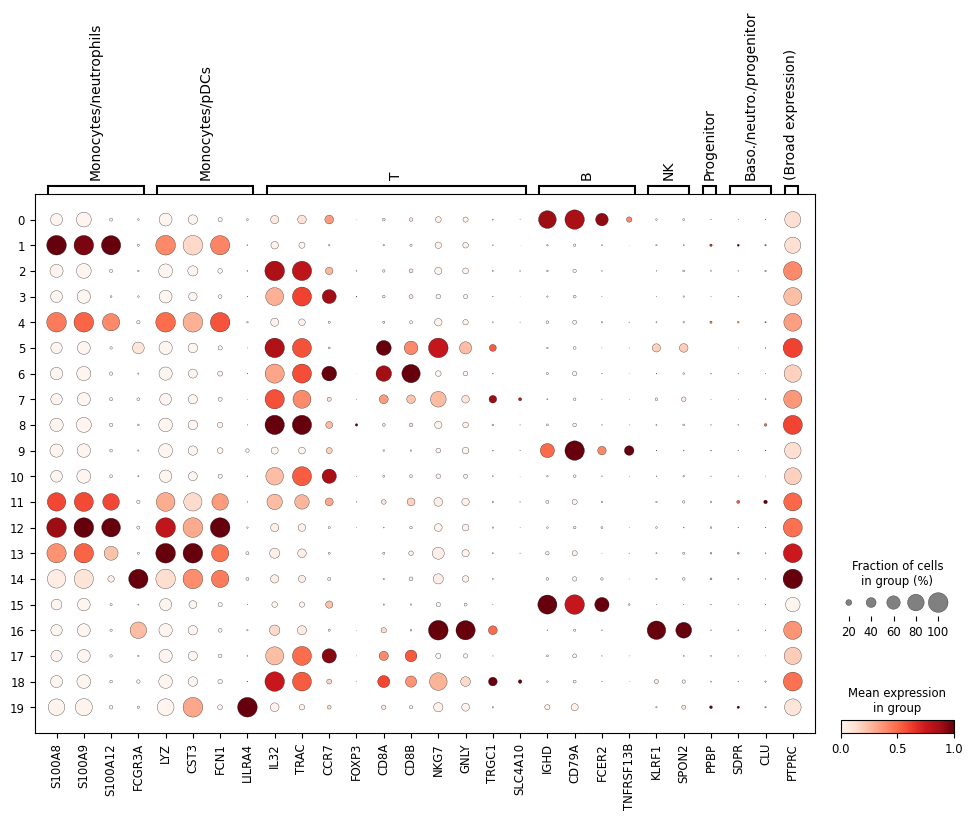

------------------------------
scAR Processed Data Dotplot


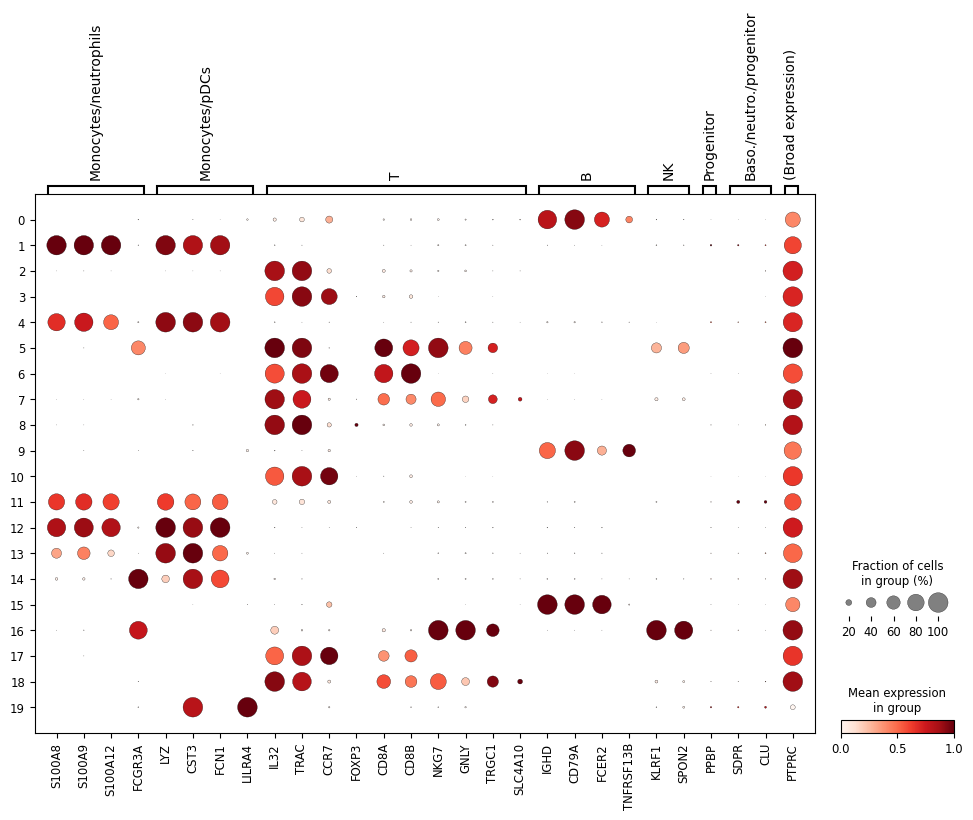

------------------------------


In [62]:
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender.png"))
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellbender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellBender Raw Data Dotplot", title_processed="CellBender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellbender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellbender.png"))
if adata_soupx:
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_soupx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="SoupX Raw Data Dotplot", title_processed="SoupX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_soupx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_soupx.png"))
if adata_decontx:
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_decontx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="DecontX Raw Data Dotplot", title_processed="DecontX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_decontx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_decontx.png"))
if adata_scar:
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar.png"))

## Bonus: runtime (on our machine)

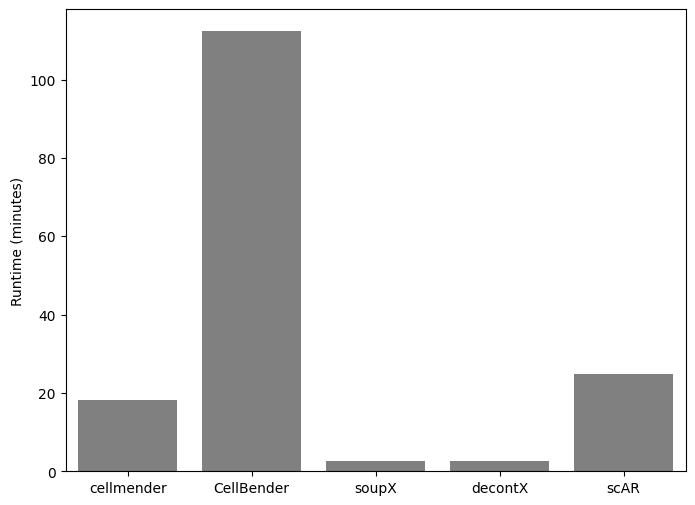

In [63]:
runtimes = {
    "cellmender": (18 + 8/60),  # 18 minutes, 8 seconds
    "CellBender": (1*60 + 52 + 20/60),  # 1 hour, 52 minutes, 20 seconds
    "soupX": (2 + 43/60),  # 2 minutes, 43 seconds
    "decontX": (2 + 37/60),  # 2 minutes, 37 seconds
    "scAR": (24 + 52/60)  # 24 minutes, 52 seconds
}

plt.figure(figsize=(8,6))
sns.barplot(x=list(runtimes.keys()), y=list(runtimes.values()), color="gray")
plt.ylabel("Runtime (minutes)")
plt.savefig(os.path.join(out_dir, "runtime_comparison.png"))
plt.show()

## Bonus: Number of parameters in cellmender and CellBender

In [64]:
cellmender_parameters = cm_utils.count_cellmender_parameters(cellmender_log_file)
print(cellmender_parameters)

12:41:52 - INFO - Number of parameters in the cellmender model: 393,247 (alpha_i: 9,000, beta: 1, gamma_type: 81,000, p_k: 303,246)


In [65]:
cellbender_parameters = cm_utils.count_cellbender_parameters(cellbender_ckpt)
print(f"Total number of parameters in the CellBender model checkpoint: {cellbender_parameters}")


=== Model Architecture (inferred from state_dict) ===
Total parameters: 843,293

encoder_z$$$network.0.layer.0.weight               | Shape: torch.Size([512, 100]) | Params: 51,200
encoder_z$$$network.0.layer.0.bias                 | Shape: torch.Size([512])    | Params: 512
encoder_z$$$loc_out.weight                         | Shape: torch.Size([64, 512]) | Params: 32,768
encoder_z$$$loc_out.bias                           | Shape: torch.Size([64])     | Params: 64
encoder_z$$$sig_out.weight                         | Shape: torch.Size([64, 512]) | Params: 32,768
encoder_z$$$sig_out.bias                           | Shape: torch.Size([64])     | Params: 64
encoder_other$$$layer1.weight                      | Shape: torch.Size([512, 104]) | Params: 53,248
encoder_other$$$layer1.bias                        | Shape: torch.Size([512])    | Params: 512
encoder_other$$$batchnorm1.weight                  | Shape: torch.Size([512])    | Params: 512
encoder_other$$$batchnorm1.bias                